In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline


In [25]:
df = pd.read_csv("height-weight.csv")
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0.5, 1.0, 'Weight vs Height')

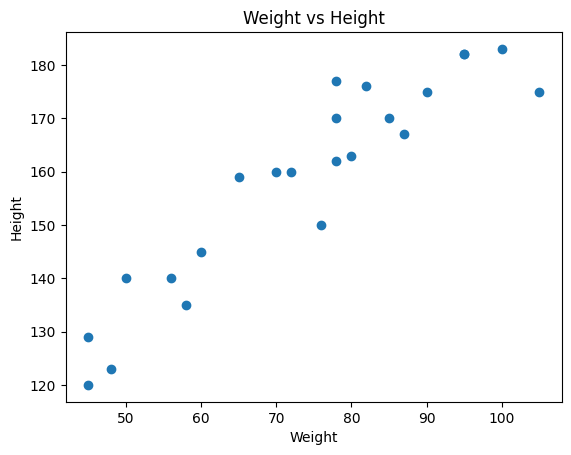

In [26]:
plt.scatter(df["Weight"], df["Height"])
plt.xlabel("Weight")
plt.ylabel("Height")
plt.title("Weight vs Height")

In [27]:
x=df[["Weight"]]
y=df["Height"]

In [28]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [29]:
x.shape

(23, 1)

In [30]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((18, 1), (5, 1), (18,), (5,))

In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


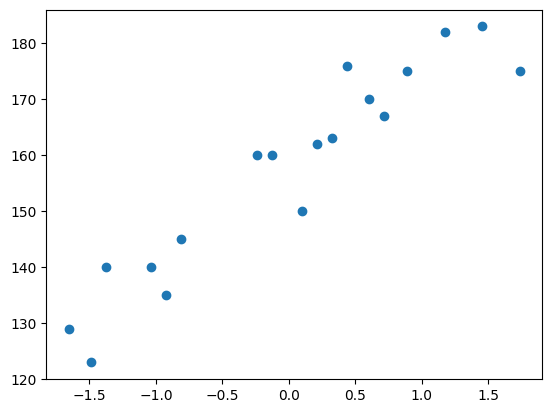

In [32]:
plt.scatter(x_train_scaled, y_train)

In [33]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train_scaled, y_train)  


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
model.coef_, model.intercept_

(array([17.03440872]), np.float64(157.5))

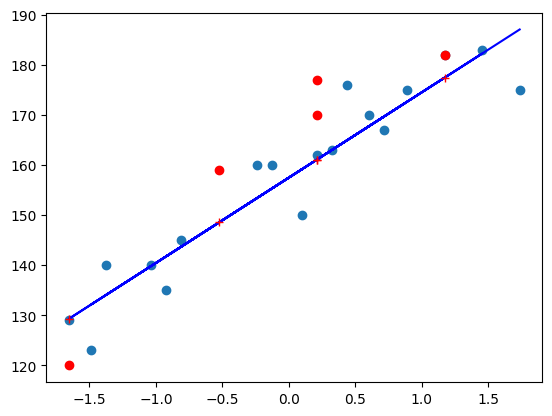

In [42]:
regression_line = model.predict(x_train_scaled)
y_pred = model.predict(x_test_scaled)
plt.scatter(x_train_scaled, y_train)
plt.scatter(x_test_scaled, y_test, color="red")
plt.plot(x_train_scaled, regression_line, color="blue")
plt.plot(x_test_scaled, y_pred, 'r+')

In [43]:
y_pred, y_test

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

In [44]:
from sklearn.metrics import mean_squared_error, r2_score,  mean_absolute_error
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
adjusted_r2 = 1 - (1-r2) * (len(y_test)-1)/(len(y_test)-x_test_scaled.shape[1]-1)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)
print("Adjusted R-squared:", adjusted_r2)


Mean Squared Error: 109.77592599051664
Mean Absolute Error: 9.822657814519232
Root Mean Squared Error: 10.477400726827081
R-squared: 0.776986986042344
Adjusted R-squared: 0.7026493147231252


In [47]:
Dan_weight = 49

Dan_weight_df = pd.DataFrame([[Dan_weight]], columns=['Weight'])
Dan_weight_scaled = scaler.transform(Dan_weight_df)

Dan_height_pred = model.predict(Dan_weight_scaled)
print(f"Predicted height for weight {Dan_weight} is: {Dan_height_pred[0]:.2f} cm")

Predicted height for weight 49 is: 133.16 cm


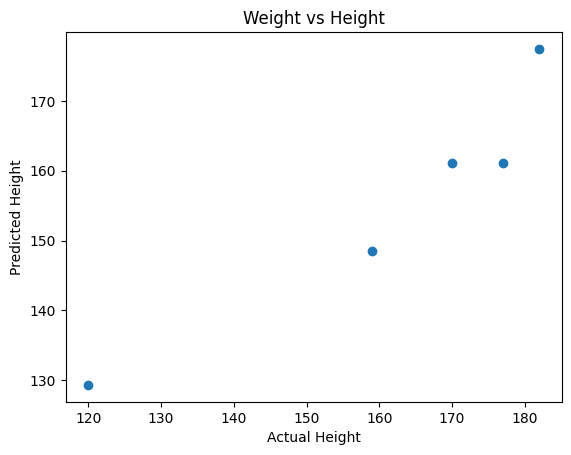

In [48]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Height")
plt.ylabel("Predicted Height")
plt.title("Weight vs Height")
plt.show()

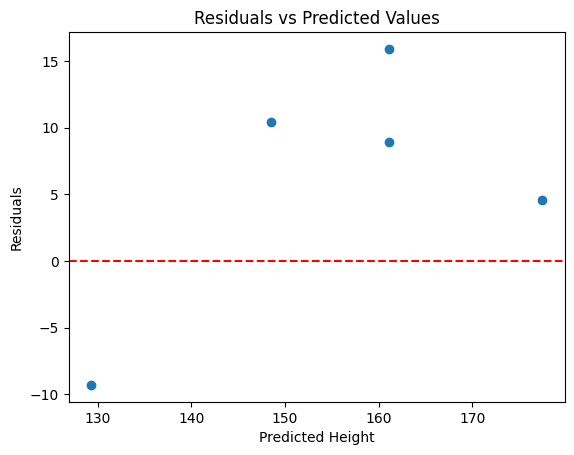

In [49]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Height")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

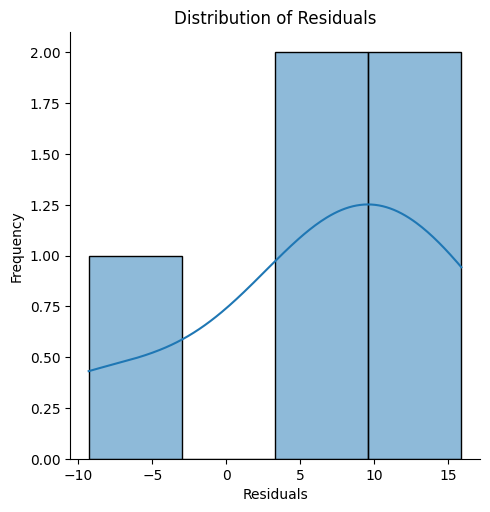

In [51]:
sns.displot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()